In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_absolute_error


In [3]:
df = pd.read_csv("Coffee_Sales.csv")
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
df.shape
df.columns
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [7]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
df = df.sort_values("date")

In [12]:
df.set_index("date" , inplace=True)

In [13]:
daily_sales = df["money"].resample("D").sum()


In [14]:
daily_sales = daily_sales.fillna(0)

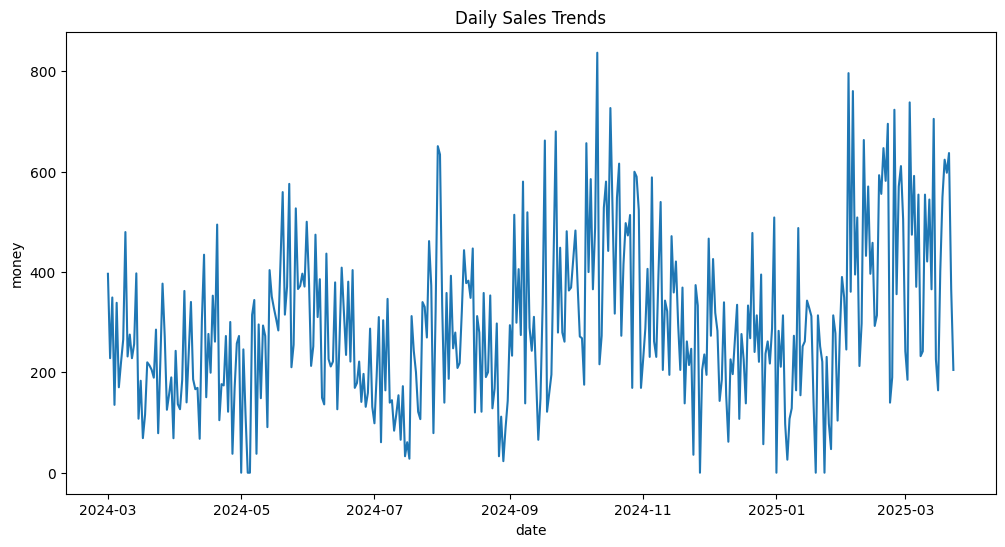

In [15]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trends")
plt.xlabel("date")
plt.ylabel("money")

plt.show()

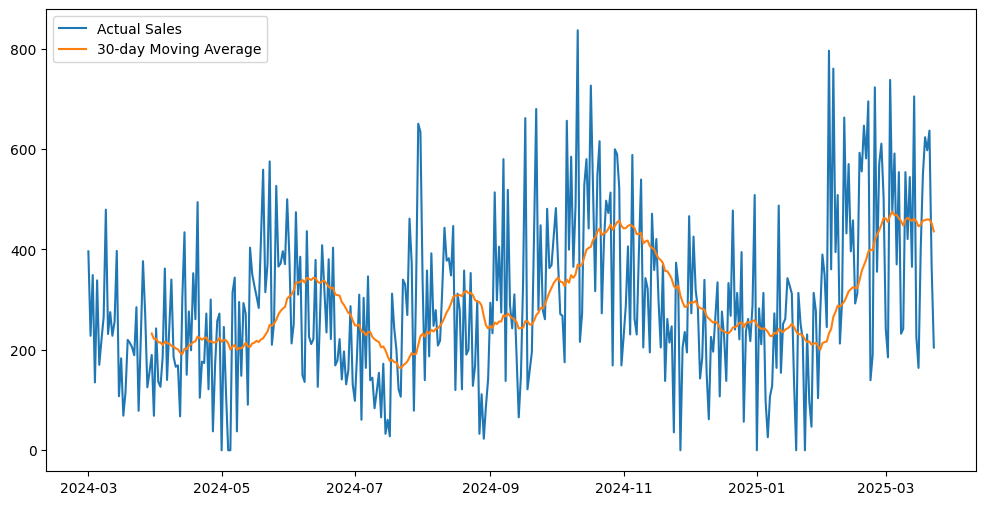

In [16]:
rolling_avg = daily_sales.rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_sales , label="Actual Sales")
plt.plot(rolling_avg , label="30-day Moving Average")

plt.legend()
plt.show()


In [17]:
train = daily_sales[:-30]
test = daily_sales[-30:]

In [18]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print (model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  money   No. Observations:                  358
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2269.225
Date:                Thu, 12 Mar 2026   AIC                           4550.449
Time:                        14:43:24   BIC                           4573.716
Sample:                    03-01-2024   HQIC                          4559.703
                         - 02-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8386      0.055    -15.307      0.000      -0.946      -0.731
ar.L2         -0.6526      0.064    -10.135      0.000      -0.779      -0.526
ar.L3         -0.4956      0.072     -6.862      0.0

In [20]:
forecast = model_fit.forecast(steps=30)


<function matplotlib.pyplot.show(close=None, block=None)>

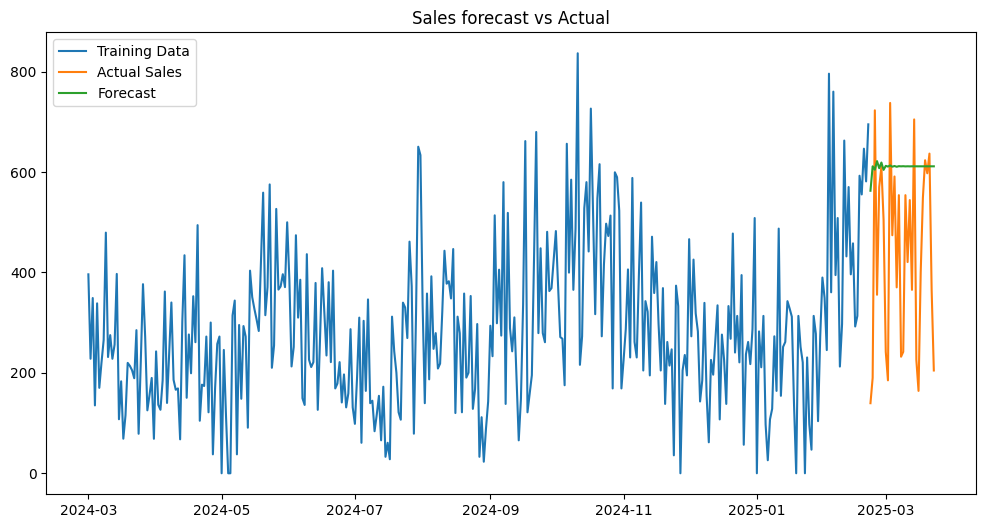

In [21]:
plt.figure(figsize=(12,6))

plt.plot(train , label="Training Data")
plt.plot(test, label="Actual Sales")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Sales forecast vs Actual")

plt.show

In [25]:
mae = mean_absolute_error   (test , forecast)
print("Mean Absolute Error:" , mae)


Mean Absolute Error: 198.79382671855737


In [26]:
future_forecast = model_fit.forecast(steps=60)

print(future_forecast)

2025-02-22    562.816490
2025-02-23    611.484212
2025-02-24    604.815566
2025-02-25    621.808410
2025-02-26    607.744050
2025-02-27    619.025459
2025-02-28    604.389766
2025-03-01    612.426488
2025-03-02    610.975343
2025-03-03    613.205689
2025-03-04    610.716244
2025-03-05    612.104140
2025-03-06    610.581314
2025-03-07    611.774799
2025-03-08    611.440654
2025-03-09    611.696927
2025-03-10    611.325465
2025-03-11    611.535643
2025-03-12    611.378751
2025-03-13    611.537013
2025-03-14    611.468715
2025-03-15    611.499601
2025-03-16    611.451324
2025-03-17    611.485005
2025-03-18    611.467172
2025-03-19    611.486162
2025-03-20    611.474177
2025-03-21    611.478716
2025-03-22    611.473043
2025-03-23    611.478158
2025-03-24    611.475725
2025-03-25    611.477860
2025-03-26    611.476032
2025-03-27    611.476813
2025-03-28    611.476171
2025-03-29    611.476880
2025-03-30    611.476502
2025-03-31    611.476744
2025-04-01    611.476496
2025-04-02    611.476632


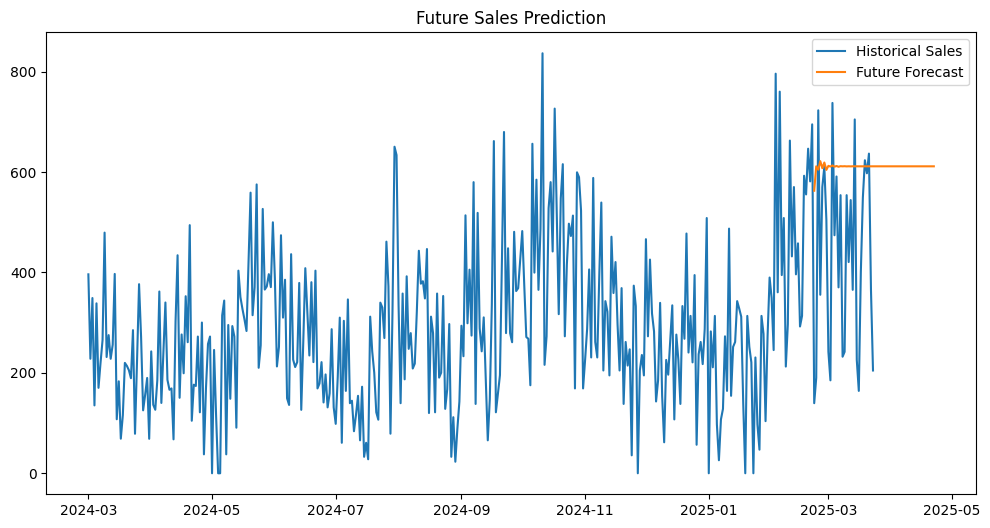

In [28]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales, label="Historical Sales")
plt.plot(future_forecast, label="Future Forecast")

plt.legend()
plt.title("Future Sales Prediction")

plt.show()

In [29]:
forecast_df = pd.DataFrame({
    "Date" : future_forecast.index,
    "Predicted_Sales":future_forecast.values
})

forecast_df.to_csv("forecast_results.csv", index=False)